<a href="https://colab.research.google.com/github/bugsotim/BSC_DPDM2025/blob/main/Final_BSC_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd


In [3]:
import pandas as pd

# ระบุเส้นทางของไฟล์ CSV
file_path = '/content/Final-BSC-2026.csv'

# อ่านไฟล์ CSV เข้าสู่ DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"อ่านไฟล์ '{file_path}' สำเร็จแล้ว ขนาด: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
    print("5 แถวแรกของข้อมูล:")
    print(df.head())
except FileNotFoundError:
    print(f"ไม่พบไฟล์ที่: {file_path}. กรุณาตรวจสอบเส้นทางไฟล์อีกครั้ง")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการอ่านไฟล์ CSV: {e}")

อ่านไฟล์ '/content/Final-BSC-2026.csv' สำเร็จแล้ว ขนาด: 13 แถว, 5 คอลัมน์
5 แถวแรกของข้อมูล:
   Day Season Humidity Cloud Cover RainFall
0    1  rainy     high       heavy     rain
1    2  rainy     high       heavy     rain
2    3  rainy     high    moderate     rain
3    4    hot      low       clear  no rain
4    5    hot      low       clear  no rain


In [7]:
df.head()

,Day,Season,Humidity,Cloud Cover,RainFall
0,1,rainy,high,heavy,rain
1,2,rainy,high,heavy,rain
2,3,rainy,high,moderate,rain
3,4,hot,low,clear,no rain
4,5,hot,low,clear,no rain


# Decision Tree 1

  MODEL 1: Decision Tree Classifier
  max_depth=3, min_samples_leaf=2

📂 โหลดข้อมูลสำเร็จ: 13 rows, 5 columns
 Day Season Humidity Cloud Cover RainFall
   1  rainy     high       heavy     rain
   2  rainy     high       heavy     rain
   3  rainy     high    moderate     rain
   4    hot      low       clear  no rain
   5    hot      low       clear  no rain
   6  rainy     high       heavy     rain
   7  rainy      NaN       heavy     rain
   8   cool   medium    moderate     rain
   9    hot      low         NaN  no rain
  10   cool   medium    moderate     rain
  11  rainy     high       heavy     rain
  12    hot      low       clear  no rain
  13   cool      NaN    moderate     rain

📊 Train set: 10 rows | Test set: 3 rows

🔧 Missing Values ก่อนแก้: 2 (train), 1 (test)
   Missing Values หลังแก้: 0 (train), 0 (test)
   เติม Season ด้วย mode = 'rainy'
   เติม Humidity ด้วย mode = 'high'
   เติม Cloud Cover ด้วย mode = 'heavy'

🔢 Label Encoding:
   Season: {'cool': np.int64(0), 'hot

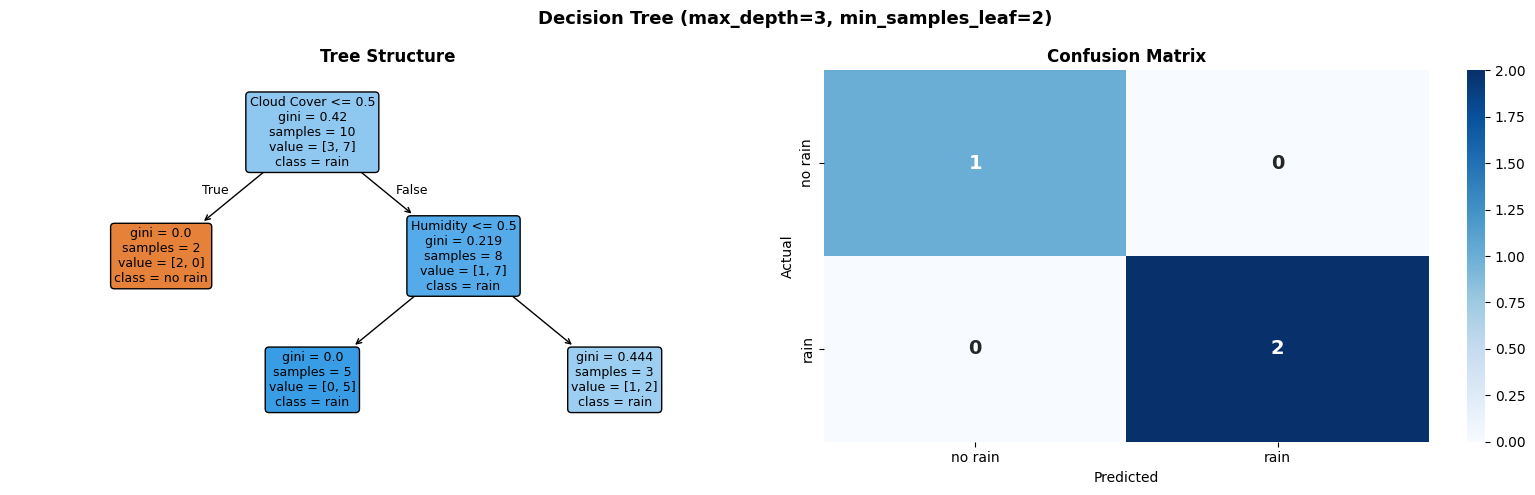

💾 บันทึกรูปเป็น model1_decision_tree_result.png


In [9]:
# ============================================================
#  MODEL 1: Decision Tree Classifier
#  จุดมุ่งหมาย: ทำนายว่าพรุ่งนี้ฝนจะตกหรือไม่
# ============================================================

# ──────────────────────────────────────────────────────────
#  🔧 ปรับค่าพารามิเตอร์ตรงนี้ได้เลย
# ──────────────────────────────────────────────────────────
DATA_PATH        = 'Final-BSC-2026.csv'   # path ของไฟล์ข้อมูล
MAX_DEPTH        = 3                       # ความลึกสูงสุดของ tree
MIN_SAMPLES_LEAF = 2                       # จำนวนตัวอย่างขั้นต่ำใน leaf
RANDOM_STATE     = 42                      # seed สำหรับ reproducibility
# ──────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("  MODEL 1: Decision Tree Classifier")
print(f"  max_depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF}")
print("=" * 55)

# ── 1. โหลดข้อมูล ──────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
# --- เพิ่ม: ลบช่องว่างนำหน้า/ท้ายในคอลัมน์ที่เป็น object ---
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
# ---------------------------------------------------------
print(f"\n📂 โหลดข้อมูลสำเร็จ: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.to_string(index=False))

# ── 2. แบ่ง Train / Test ────────────────────────────────────
train_df = df.iloc[:10].copy()   # แถว 1-10
test_df  = df.iloc[10:].copy()   # แถว 11-13

print(f"\n📊 Train set: {len(train_df)} rows | Test set: {len(test_df)} rows")

feature_cols = ['Season', 'Humidity', 'Cloud Cover']
target_col   = 'RainFall'

X_train_raw = train_df[feature_cols]
y_train_raw = train_df[target_col]
X_test_raw  = test_df[feature_cols]
y_test_raw  = test_df[target_col]

# ── 3. จัดการ Missing Values ────────────────────────────────
print(f"\n🔧 Missing Values ก่อนแก้: {X_train_raw.isnull().sum().sum()} (train), {X_test_raw.isnull().sum().sum()} (test)")

imputer     = SimpleImputer(strategy='most_frequent')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),      columns=feature_cols)

print(f"   Missing Values หลังแก้: {X_train_imp.isnull().sum().sum()} (train), {X_test_imp.isnull().sum().sum()} (test)")
for col in feature_cols:
    print(f"   เติม {col} ด้วย mode = '{X_train_raw[col].mode()[0]}'")

# ── 4. Label Encoding ───────────────────────────────────────
print("\n🔢 Label Encoding:")
encoders    = {}
X_train_enc = X_train_imp.copy()
X_test_enc  = X_test_imp.copy()

for col in feature_cols:
    le = LabelEncoder()
    le.fit(X_train_imp[col])
    X_train_enc[col] = le.transform(X_train_imp[col])
    X_test_enc[col]  = le.transform(X_test_imp[col])
    encoders[col]    = le
    print(f"   {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

le_target = LabelEncoder()
le_target.fit(y_train_raw)
y_train = le_target.transform(y_train_raw)
y_test  = le_target.transform(y_test_raw)
print(f"   {target_col}: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# ── 5. Train Model ──────────────────────────────────────────
print(f"\n🤖 Training Decision Tree...")
print(f"   max_depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF}")

model = DecisionTreeClassifier(
    max_depth        = MAX_DEPTH,
    min_samples_leaf = MIN_SAMPLES_LEAF,
    random_state     = RANDOM_STATE
)
model.fit(X_train_enc, y_train)

print(f"   Tree depth จริง: {model.get_depth()}")
print(f"   จำนวน leaves  : {model.get_n_leaves()}")
print(f"\n   Feature Importance:")
for feat, imp in zip(feature_cols, model.feature_importances_):
    bar = '█' * int(imp * 20)
    print(f"     {feat:15s}: {imp:.4f}  {bar}")

# ── 6. Predict ──────────────────────────────────────────────
y_pred = model.predict(X_test_enc)

print(f"\n🔮 ผลการทำนาย Test Set:")
print(f"{'Row':<6} {'Actual':<12} {'Predicted':<12} {'Correct?'}")
print("-" * 45)
for i in range(len(y_test)):
    actual = le_target.inverse_transform([y_test[i]])[0]
    pred   = le_target.inverse_transform([y_pred[i]])[0]
    ok     = "✓" if y_pred[i] == y_test[i] else "✗"
    print(f"{11+i:<6} {actual:<12} {pred:<12} {ok}")

# ── 7. Performance Metrics ──────────────────────────────────
print("\n📈 Performance Metrics (Test Set):")
print("-" * 40)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0, pos_label=1)
rec  = recall_score(y_test, y_pred, zero_division=0, pos_label=1)
f1   = f1_score(y_test, y_pred, zero_division=0, pos_label=1)
cm   = confusion_matrix(y_test, y_pred, labels=[0, 1])

print(f"  Accuracy  = {acc:.4f}")
print(f"  Precision = {prec:.4f}")
print(f"  Recall    = {rec:.4f}")
print(f"  F1-Score  = {f1:.4f}")
print(f"\n  Confusion Matrix:")
print(f"  [[TN={cm[0,0]}, FP={cm[0,1]}],")
print(f"   [FN={cm[1,0]}, TP={cm[1,1]}]]")
print(f"\n{classification_report(y_test, y_pred, target_names=le_target.classes_, zero_division=0)}")

# ── 8. Visualize Tree ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Decision Tree (max_depth={MAX_DEPTH}, min_samples_leaf={MIN_SAMPLES_LEAF})',
             fontsize=13, fontweight='bold')

# Tree structure
plot_tree(model, feature_names=feature_cols, class_names=le_target.classes_,
          filled=True, rounded=True, fontsize=9, ax=axes[0],
          impurity=True, proportion=False, precision=3)
axes[0].set_title('Tree Structure', fontweight='bold')

# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model1_decision_tree_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกรูปเป็น model1_decision_tree_result.png")

# Naive Bayes

In [12]:
# ============================================================
#  MODEL 2: Naive Bayes Classifier (CategoricalNB)
#  จุดมุ่งหมาย: ทำนายว่าพรุ่งนี้ฝนจะตกหรือไม่
# ============================================================

# ──────────────────────────────────────────────────────────
#  🔧 ปรับค่าพารามิเตอร์ตรงนี้ได้เลย
# ──────────────────────────────────────────────────────────
DATA_PATH = 'Final-BSC-2026.csv'   # path ของไฟล์ข้อมูล
ALPHA      = 1.0                    # Laplace smoothing (0 = ไม่ smooth, 1 = default)
# ──────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("  MODEL 2: Naive Bayes Classifier (CategoricalNB)")
print(f"  alpha={ALPHA} (Laplace smoothing)")
print("=" * 55)

  MODEL 2: Naive Bayes Classifier (CategoricalNB)
  alpha=1.0 (Laplace smoothing)



📂 โหลดข้อมูลสำเร็จ: 13 rows, 5 columns
 Day Season Humidity Cloud Cover RainFall
   1  rainy     high       heavy     rain
   2  rainy     high       heavy     rain
   3  rainy     high    moderate     rain
   4    hot      low       clear  no rain
   5    hot      low       clear  no rain
   6  rainy     high       heavy     rain
   7  rainy      NaN       heavy     rain
   8   cool   medium    moderate     rain
   9    hot      low         NaN  no rain
  10   cool   medium    moderate     rain
  11  rainy     high       heavy     rain
  12    hot      low       clear  no rain
  13   cool      NaN    moderate     rain

📊 Train set: 10 rows | Test set: 3 rows

🔧 Missing Values ก่อนแก้: 2 (train), 1 (test)
   Missing Values หลังแก้: 0 (train), 0 (test)
   เติม Season ด้วย mode = 'rainy'
   เติม Humidity ด้วย mode = 'high'
   เติม Cloud Cover ด้วย mode = 'heavy'

🔢 Label Encoding:
   Season: {'cool': np.int64(0), 'hot': np.int64(1), 'rainy': np.int64(2)}
   Humidity: {'high': np.int64(0

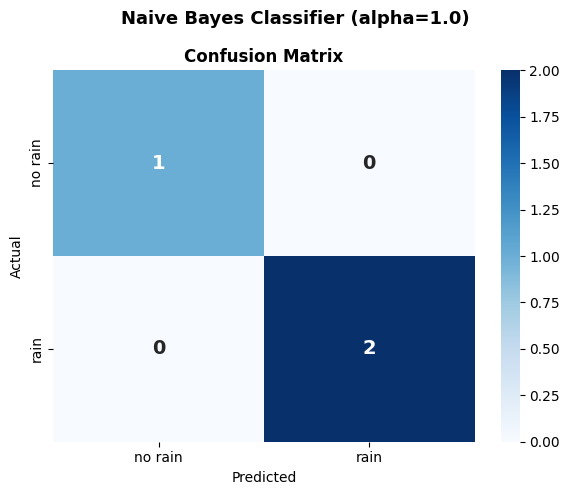

💾 บันทึกรูปเป็น model2_naive_bayes_result.png


In [13]:
# ── 1. โหลดข้อมูล ──────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
# --- เพิ่ม: ลบช่องว่างนำหน้า/ท้ายในคอลัมน์ที่เป็น object เพื่อป้องกันปัญหา whitespace ---
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
# ----------------------------------------------------------------------------------
print(f"\n📂 โหลดข้อมูลสำเร็จ: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.to_string(index=False))

# ── 2. แบ่ง Train / Test ────────────────────────────────────
train_df = df.iloc[:10].copy()   # แถว 1-10
test_df  = df.iloc[10:].copy()   # แถว 11-13

print(f"\n📊 Train set: {len(train_df)} rows | Test set: {len(test_df)} rows")

feature_cols = ['Season', 'Humidity', 'Cloud Cover']
target_col   = 'RainFall'

X_train_raw = train_df[feature_cols]
y_train_raw = train_df[target_col]
X_test_raw  = test_df[feature_cols]
y_test_raw  = test_df[target_col]

# ── 3. จัดการ Missing Values ────────────────────────────────
print(f"\n🔧 Missing Values ก่อนแก้: {X_train_raw.isnull().sum().sum()} (train), {X_test_raw.isnull().sum().sum()} (test)")

imputer     = SimpleImputer(strategy='most_frequent')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),      columns=feature_cols)

print(f"   Missing Values หลังแก้: {X_train_imp.isnull().sum().sum()} (train), {X_test_imp.isnull().sum().sum()} (test)")
for col in feature_cols:
    print(f"   เติม {col} ด้วย mode = '{X_train_raw[col].mode()[0]}'")

# ── 4. Label Encoding ───────────────────────────────────────
print("\n🔢 Label Encoding:")
encoders    = {}
X_train_enc = X_train_imp.copy()
X_test_enc  = X_test_imp.copy()

for col in feature_cols:
    le = LabelEncoder()
    le.fit(X_train_imp[col])
    X_train_enc[col] = le.transform(X_train_imp[col])
    X_test_enc[col]  = le.transform(X_test_imp[col])
    encoders[col]    = le
    print(f"   {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

le_target = LabelEncoder()
le_target.fit(y_train_raw)
y_train = le_target.transform(y_train_raw)
y_test  = le_target.transform(y_test_raw)
print(f"   {target_col}: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# ── 5. Train Model ──────────────────────────────────────────
print(f"\n🤖 Training Naive Bayes Classifier...")
print(f"   alpha={ALPHA}")

model_nb = CategoricalNB(alpha=ALPHA)
model_nb.fit(X_train_enc, y_train)

# ── 6. Predict ──────────────────────────────────────────────
y_pred_nb = model_nb.predict(X_test_enc)

print(f"\n🔮 ผลการทำนาย Test Set (Naive Bayes):")
print(f"{'Row':<6} {'Actual':<12} {'Predicted':<12} {'Correct?'}")
print("-" * 45)
for i in range(len(y_test)):
    actual = le_target.inverse_transform([y_test[i]])[0]
    pred   = le_target.inverse_transform([y_pred_nb[i]])[0]
    ok     = "✓" if y_pred_nb[i] == y_test[i] else "✗"
    print(f"{11+i:<6} {actual:<12} {pred:<12} {ok}")

# ── 7. Performance Metrics ──────────────────────────────────
print("\n📈 Performance Metrics (Test Set - Naive Bayes):")
print("-" * 40)
acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0, pos_label=1)
rec_nb  = recall_score(y_test, y_pred_nb, zero_division=0, pos_label=1)
f1_nb   = f1_score(y_test, y_pred_nb, zero_division=0, pos_label=1)
cm_nb   = confusion_matrix(y_test, y_pred_nb, labels=[0, 1])

print(f"  Accuracy  = {acc_nb:.4f}")
print(f"  Precision = {prec_nb:.4f}")
print(f"  Recall    = {rec_nb:.4f}")
print(f"  F1-Score  = {f1_nb:.4f}")
print(f"\n  Confusion Matrix:")
print(f"  [[TN={cm_nb[0,0]}, FP={cm_nb[0,1]}],")
print(f"   [FN={cm_nb[1,0]}, TP={cm_nb[1,1]}]]")
print(f"\n{classification_report(y_test, y_pred_nb, target_names=le_target.classes_, zero_division=0)}")

# ── 8. Visualize Confusion Matrix ───────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle(f'Naive Bayes Classifier (alpha={ALPHA})', fontsize=13, fontweight='bold')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            annot_kws={'size': 14, 'weight': 'bold'})
axes.set_title('Confusion Matrix', fontweight='bold')
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model2_naive_bayes_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกรูปเป็น model2_naive_bayes_result.png")